## Dataset Understanding

**Imports and file paths**

In [1]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

DATA_ROOT = Path("../dataset/data")
CONSUMPTION = DATA_ROOT / "consumption_data"
SURVEY = DATA_ROOT / "survey_data"

SIX_HOUR_FILES = sorted(glob.glob(str(CONSUMPTION / "smart_meter" / "6hour_interval" / "smart_6hour_*.csv")))
FIFTEEN_MIN_FILES = sorted(glob.glob(str(CONSUMPTION / "smart_meter" / "15min_interval" / "smart_15min_*.csv")))
MONTHLY_FILE = CONSUMPTION / "non_smart_meter" / "monthly_consumption.csv"

print(f"6-hour interval files:  {len(SIX_HOUR_FILES)}")
print(f"15-min interval files:  {len(FIFTEEN_MIN_FILES)}")
print(f"Monthly file exists:    {MONTHLY_FILE.exists()}")


6-hour interval files:  5
15-min interval files:  3
Monthly file exists:    True


**Profile the monthly (non-smart-meter) file**

In [2]:
monthly = pd.read_csv(MONTHLY_FILE)

print("Shape:", monthly.shape)
display(monthly.info())
print("\nNull counts:")
display(monthly.isna().sum())
print("\nUnique households:", monthly["household_ID"].nunique())
print("Month range:", monthly["month"].min(), "->", monthly["month"].max())
monthly.head()


Shape: (101575, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101575 entries, 0 to 101574
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   household_ID  101575 non-null  object
 1   month         101575 non-null  object
 2   consumption   100985 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB


None


Null counts:


household_ID      0
month             0
consumption     590
dtype: int64


Unique households: 4063
Month range: 2022-10-31 -> 2024-10-31


,household_ID,month,consumption
0,ID0001,2022-10-31,116
1,ID0001,2022-11-30,120
2,ID0001,2022-12-31,129
3,ID0001,2023-01-31,102
4,ID0001,2023-02-28,115


In [3]:
# Consumption Distribution of monthly none-smart-meters
monthly["consumption"].describe()

count     100985
unique      1134
top            0
freq        2332
Name: consumption, dtype: object

In [4]:
# Finding what breaks numeric parsing
print(monthly["consumption"].dtype)

non_numeric = monthly[pd.to_numeric(monthly["consumption"], errors="coerce").isna() & monthly["consumption"].notna()]
print("Rows that fail numeric parsing:", len(non_numeric))
non_numeric["consumption"].value_counts().head(20)

object
Rows that fail numeric parsing: 57


consumption
1,159    2
1,476    2
1,701    1
1,346    1
1,399    1
1,297    1
1,644    1
1,197    1
1,332    1
1,498    1
1,652    1
1,627    1
1,653    1
1,299    1
1,481    1
1,475    1
1,414    1
1,771    1
1,316    1
1,031    1
Name: count, dtype: int64

In [5]:
# Recheck the distribution with commas stripped
consumption_clean = pd.to_numeric(monthly["consumption"].str.replace(",", "", regex=False), errors="coerce")
consumption_clean.describe()


count    100985.000000
mean        122.144120
std         122.217922
min           0.000000
25%          60.000000
50%          96.000000
75%         148.000000
max        3025.000000
Name: consumption, dtype: float64

In [6]:
def profile_large_csv(path: str, date_col: str, id_col: str, chunksize: int = 100000) -> dict:
    """Chunked profiling pass: row count, dtypes, null counts, unique households, date span."""
    n_rows = 0
    null_counts = None
    dtypes = None
    households = set()
    date_min, date_max = None, None

    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        n_rows += len(chunk)
        if dtypes is None:
            dtypes = chunk.dtypes

        chunk_nulls = chunk.isna().sum()
        null_counts = chunk_nulls if null_counts is None else null_counts.add(chunk_nulls, fill_value=0)

        households.update(chunk[id_col].unique())

        c_min, c_max = chunk[date_col].min(), chunk[date_col].max()
        date_min = c_min if date_min is None else min(date_min, c_min)
        date_max = c_max if date_max is None else max(date_max, c_max)

    return {
        "file": os.path.basename(path),
        "n_rows": n_rows,
        "n_columns": len(dtypes),
        "n_households": len(households),
        "date_min": date_min,
        "date_max": date_max,
        "dtypes": dtypes,
        "null_counts": null_counts,
        "households": households,
    }

test_profile = profile_large_csv(SIX_HOUR_FILES[-1], date_col="DATE", id_col="household_ID")
print(test_profile["file"], test_profile["n_rows"], test_profile["date_min"], "->", test_profile["date_max"])
print(test_profile["dtypes"])


smart_6hour_5.csv 279467 2024-09-02 -> 2024-12-31
household_ID                     object
BRANCH                           object
DEPOT                            object
substation_ID                    object
SUB_TYPE                         object
E_BILLING                          bool
EXPORT                             bool
DATE                             object
TIME                             object
TOTAL_IMPORT (kWh)              float64
TOTAL_EXPORT (kWh)              float64
TOTAL_IMPORT - PV1 (kWh)        float64
TOTAL_EXPORT - PV1 (kWh)        float64
TR1_TOTAL_IMPORT (kWh)          float64
TR2_TOTAL_IMPORT (kWh)          float64
TR3_TOTAL_IMPORT (kWh)          float64
TR1_TOTAL_EXPORT (kWh)          float64
TR2_TOTAL_EXPORT (kWh)          float64
TR3_TOTAL_EXPORT (kWh)          float64
TR1_TOTAL_IMPORT - PV1 (kWh)    float64
TR2_TOTAL_IMPORT - PV1 (kWh)    float64
TR3_TOTAL_IMPORT - PV1 (kWh)    float64
TR1_TOTAL_EXPORT - PV1 (kWh)    float64
TR2_TOTAL_EXPORT - PV1 (kWh)  

**Profile all 6-hour interval files**

In [7]:
six_hour_profiles = [profile_large_csv(f, date_col="DATE", id_col="household_ID") for f in SIX_HOUR_FILES]

six_hour_summary = pd.DataFrame([
    {k: v for k, v in p.items() if k not in ("dtypes", "null_counts", "households")}
    for p in six_hour_profiles
])
six_hour_summary


,file,n_rows,n_columns,n_households,date_min,date_max
0,smart_6hour_1.csv,1115230,32,2813,2023-01-01,2023-06-01
1,smart_6hour_2.csv,1319347,32,2922,2023-06-02,2023-11-01
2,smart_6hour_3.csv,1047075,32,2950,2023-11-02,2024-04-01
3,smart_6hour_4.csv,680674,32,2929,2024-04-02,2024-09-01
4,smart_6hour_5.csv,279467,32,2911,2024-09-02,2024-12-31


**Total unique households + missing-value profile**

In [8]:
print("Total rows across all 6-hour files:", six_hour_summary["n_rows"].sum())

all_six_hour_households = set()
for p in six_hour_profiles:
    all_six_hour_households |= p["households"]
print("Unique households across all 5 files combined:", len(all_six_hour_households))

combined_nulls = None
combined_rows = 0
for p in six_hour_profiles:
    combined_rows += p["n_rows"]
    combined_nulls = p["null_counts"] if combined_nulls is None else combined_nulls.add(p["null_counts"], fill_value=0)

null_rate = (combined_nulls / combined_rows * 100).sort_values(ascending=False)
null_rate.head(10)


Total rows across all 6-hour files: 4441793
Unique households across all 5 files combined: 2950


PHASE_C_VOLTAGE (V)             87.157461
PHASE_B_VOLTAGE (V)             87.157461
PHASE_C_CURRENT (A)             87.157371
PHASE_B_CURRENT (A)             87.157371
TR1_TOTAL_EXPORT (kWh)           0.000450
TR1_TOTAL_EXPORT - PV1 (kWh)     0.000338
TOTAL_EXPORT (kWh)               0.000315
TOTAL_IMPORT (kWh)               0.000293
TR2_TOTAL_EXPORT (kWh)           0.000293
TR3_TOTAL_EXPORT (kWh)           0.000293
dtype: float64

**Profile the 15-min interval files**

In [9]:
fifteen_min_profiles = [profile_large_csv(f, date_col="date", id_col="household_ID") for f in FIFTEEN_MIN_FILES]

fifteen_min_summary = pd.DataFrame([
    {k: v for k, v in p.items() if k not in ("dtypes", "null_counts", "households")}
    for p in fifteen_min_profiles
])
fifteen_min_summary


,file,n_rows,n_columns,n_households,date_min,date_max
0,smart_15min_1.csv,9435755,20,2373,2023-10-01,2024-03-01
1,smart_15min_2.csv,16425676,20,2878,2024-03-02,2024-08-01
2,smart_15min_3.csv,19751849,20,2745,2024-08-02,2024-12-23


**Total rows/households + missing-value profile for the 15-min files**

In [10]:
print("Total rows across all 15-min files:", fifteen_min_summary["n_rows"].sum())

all_15min_households = set()
for p in fifteen_min_profiles:
    all_15min_households |= p["households"]
print("Unique households across all 3 files combined:", len(all_15min_households))

combined_nulls_15 = None
combined_rows_15 = 0
for p in fifteen_min_profiles:
    combined_rows_15 += p["n_rows"]
    combined_nulls_15 = p["null_counts"] if combined_nulls_15 is None else combined_nulls_15.add(p["null_counts"], fill_value=0)

null_rate_15 = (combined_nulls_15 / combined_rows_15 * 100).sort_values(ascending=False)
null_rate_15.head(10)


Total rows across all 15-min files: 45613280
Unique households across all 3 files combined: 2938


phasecinstvoltage(v)    86.032671
phasecinstcurrent(a)    86.032671
phasebinstvoltage(v)    86.032671
phasebinstcurrent(a)    86.032671
importkvarh(kvarh)      86.030312
exportkvarh(kvarh)      86.030312
phaseainstvoltage(v)    83.250060
phaseainstcurrent(a)    83.250060
avgvoltage(v)           16.678410
avgcurrent(v)           16.678410
dtype: float64

**Profile the 3 survey waves**

In [11]:
survey_rows = []
for wave in ("wave_1", "wave_2", "wave_3"):
    wave_dir = SURVEY / wave
    for f in sorted(glob.glob(str(wave_dir / "*.csv"))):
        df = pd.read_csv(f, dtype={9:str})
        survey_rows.append({
            "wave": wave,
            "table": os.path.basename(f),
            "n_rows": len(df),
            "n_columns": df.shape[1],
            "has_household_id": "household_ID" in df.columns,
        })

survey_summary = pd.DataFrame(survey_rows)
survey_summary


,wave,table,n_rows,n_columns,has_household_id
0,wave_1,w1_ac_roster.csv,1171,10,True
1,wave_1,w1_appliances.csv,53599,4,True
2,wave_1,w1_demographics.csv,16270,16,True
3,wave_1,w1_electricity_generation_water_heating_cookin...,4063,36,True
4,wave_1,w1_fan_roster.csv,13525,6,True
5,wave_1,w1_household_information_and_history.csv,4063,26,True
6,wave_1,w1_light_roster.csv,48489,7,True
7,wave_1,w1_room_roster.csv,36408,16,True
8,wave_2,w2_ac_roster.csv,854,9,True
9,wave_2,w2_appliance_usage.csv,41594,4,True


In [12]:
# Survey Dates csv
survey_dates = pd.read_csv(SURVEY / "survey_dates.csv")
print("Shape:", survey_dates.shape)
survey_dates.head()

Shape: (4063, 5)


,Unnamed: 0,household_ID,wave1,wave2,wave3
0,0,ID0285,01/03/2024,NaN,NaN
1,1,ID0603,01/08/2024,NaN,NaN
2,2,ID0601,01/08/2024,10/23/2024,01/10/2025
3,3,ID0600,01/08/2024,10/23/2024,12/28/2024
4,4,ID0715,01/10/2024,10/23/2024,12/29/2024


**Pull a handful of households' raw readings and plot the cumulative counter**

Sample households: ['ID0013', 'ID0018', 'ID0041', 'ID0043', 'ID0052']


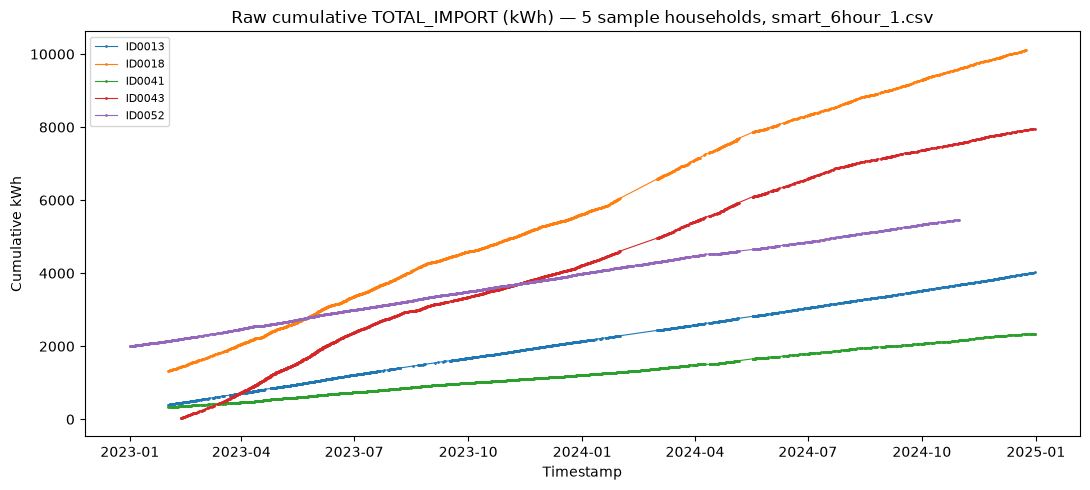

In [13]:
sample_households = sorted(list(six_hour_profiles[0]["households"]))[:5]
print("Sample households:", sample_households)

sample_rows = []
for file in SIX_HOUR_FILES:
    for chunk in pd.read_csv(file, chunksize=100000, low_memory=False):
        match = chunk[chunk["household_ID"].isin(sample_households)]
        if len(match):
            sample_rows.append(match)

sample_df = pd.concat(sample_rows, ignore_index=True)

# Chunked reads can infer dtype independently per chunk — if any chunk has a
# stray non-numeric value, concatenating chunks of different dtypes silently
# produces an object column. Coerce explicitly rather than trusting the dtype.
sample_df["TOTAL_IMPORT (kWh)"] = pd.to_numeric(sample_df["TOTAL_IMPORT (kWh)"], errors="coerce")
sample_df["timestamp"] = pd.to_datetime(sample_df["DATE"] + " " + sample_df["TIME"])
sample_df = sample_df.sort_values(["household_ID", "timestamp"])

fig, ax = plt.subplots(figsize=(11, 5))
for hh, grp in sample_df.groupby("household_ID"):
    ax.plot(grp["timestamp"], grp["TOTAL_IMPORT (kWh)"], label=hh, marker=".", markersize=2, linewidth=0.8)
ax.set_title("Raw cumulative TOTAL_IMPORT (kWh) — 5 sample households, smart_6hour_1.csv")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative kWh")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Count how often the counter actually resets (negative diffs)**

In [14]:
diffs = sample_df.groupby("household_ID")["TOTAL_IMPORT (kWh)"].diff()
n_negative = (diffs < 0).sum()
n_total = diffs.notna().sum()
print(f"Negative interval diffs (counter resets) in this sample: {n_negative} / {n_total} ({n_negative / n_total * 100:.2f}%)")
diffs.describe()


Negative interval diffs (counter resets) in this sample: 0 / 7400 (0.00%)


count    7400.000000
mean        3.489523
std         8.788104
min         0.000000
25%         1.079000
50%         2.151950
75%         4.394475
max       524.345000
Name: TOTAL_IMPORT (kWh), dtype: float64